# S&P 500 Clustering with Feature Mix (Baseline + Forecasting6 Engineered)

This notebook extends the `sp500_clustering_full_mean_std.ipynb` Section 6 approach by testing:
- original clustering feature cases (baseline)
- engineered features from `forecasting6.ipynb`
- hybrid mix-and-match feature sets

It compares train/validation/test clustering scores and consistency to check whether engineered features help.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## 1) Load Data

Using the same source file and split dates as the clustering notebook.


In [3]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Min date:", df["Date"].min())
print("Max date:", df["Date"].max())
print("Rows:", len(df))
print("Stocks:", df["Symbol"].nunique())

df.head()


Min date: 2021-03-22 00:00:00
Max date: 2026-03-20 00:00:00
Rows: 626169
Stocks: 503


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
0,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
1,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
2,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005
3,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005
4,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005


## 2) Feature Engineering Functions

- `create_features`: baseline clustering notebook features
- `engineer_features`: forecasting6 engineered features


In [4]:
def create_features(panel_df):
    panel_df = panel_df.copy()
    panel_df = panel_df.sort_values(["Symbol", "Date"])

    panel_df["log_close"] = np.log(panel_df["Close"])

    panel_df["logret_1"] = panel_df.groupby("Symbol")["log_close"].diff(1)
    panel_df["logret_5"] = panel_df.groupby("Symbol")["log_close"].diff(5)
    panel_df["logret_21"] = panel_df.groupby("Symbol")["log_close"].diff(21)

    panel_df["logvol_1"] = panel_df.groupby("Symbol")["logret_1"].rolling(2).std().reset_index(level=0, drop=True)
    panel_df["logvol_5"] = panel_df.groupby("Symbol")["logret_1"].rolling(5).std().reset_index(level=0, drop=True)
    panel_df["logvol_21"] = panel_df.groupby("Symbol")["logret_1"].rolling(21).std().reset_index(level=0, drop=True)

    panel_df["log_volume"] = np.log(panel_df["Volume"].clip(lower=1))
    panel_df["vol_chg_1"] = panel_df.groupby("Symbol")["log_volume"].diff(1)
    panel_df["vol_chg_5"] = panel_df.groupby("Symbol")["log_volume"].diff(5)
    panel_df["vol_chg_21"] = panel_df.groupby("Symbol")["log_volume"].diff(21)

    return panel_df


def engineer_features(panel_df):
    panel_df = panel_df.copy()
    panel_df = panel_df.sort_values(["Symbol", "Date"])

    g = panel_df.groupby("Symbol")

    panel_df["ret_1"] = g["Close"].pct_change()
    panel_df["ret_abs_1"] = panel_df["ret_1"].abs()

    for w in [5, 10, 21]:
        panel_df[f"ret_std_{w}"] = g["ret_1"].transform(lambda s: s.rolling(w).std())

    panel_df["hl_range"] = (panel_df["High"] - panel_df["Low"]) / panel_df["Close"]

    for w in [5, 21]:
        panel_df[f"hl_range_mean_{w}"] = g["hl_range"].transform(lambda s: s.rolling(w).mean())

    for w in [5, 21]:
        panel_df[f"vol_mean_{w}"] = g["Volume"].transform(lambda s: s.rolling(w).mean())
        panel_df[f"vol_rel_{w}"] = panel_df["Volume"] / panel_df[f"vol_mean_{w}"]

    return panel_df


## 3) Split by Time and Build Feature Tables

Split windows (same as `sp500_clustering_full_mean_std.ipynb`):
- train: 2021-03-22 to 2024-03-21
- validation: 2024-03-22 to 2025-03-21
- test: 2025-03-22 to 2026-03-21


In [5]:
train_raw = df[(df["Date"] >= "2021-03-22") & (df["Date"] <= "2024-03-21")].copy()
val_raw = df[(df["Date"] >= "2024-03-22") & (df["Date"] <= "2025-03-21")].copy()
test_raw = df[(df["Date"] >= "2025-03-22") & (df["Date"] <= "2026-03-21")].copy()

common_symbols = (
    set(train_raw["Symbol"].unique())
    & set(val_raw["Symbol"].unique())
    & set(test_raw["Symbol"].unique())
)

train_raw = train_raw[train_raw["Symbol"].isin(common_symbols)].copy()
val_raw = val_raw[val_raw["Symbol"].isin(common_symbols)].copy()
test_raw = test_raw[test_raw["Symbol"].isin(common_symbols)].copy()

train = engineer_features(create_features(train_raw))
val = engineer_features(create_features(val_raw))
test = engineer_features(create_features(test_raw))

print("Common stocks:", len(common_symbols))
print("Train rows:", len(train), "Stocks:", train["Symbol"].nunique())
print("Val rows:", len(val), "Stocks:", val["Symbol"].nunique())
print("Test rows:", len(test), "Stocks:", test["Symbol"].nunique())


Common stocks: 499
Train rows: 375299 Stocks: 499
Val rows: 124750 Stocks: 499
Test rows: 124749 Stocks: 499


## 4) Define Feature Cases (Baseline, Engineered, Hybrid)

In [6]:
FEATURE_CASES = {
    # Baseline Section 6 cases
    "baseline_case_1": {
        "family": "baseline",
        "features": ["logret_1", "logvol_1", "vol_chg_1"],
    },
    "baseline_case_2": {
        "family": "baseline",
        "features": ["logret_5", "logvol_5", "vol_chg_5"],
    },
    "baseline_case_3": {
        "family": "baseline",
        "features": ["logret_21", "logvol_21", "vol_chg_21"],
    },

    # Forecasting6 engineered-only cases
    "eng_case_short": {
        "family": "engineered",
        "features": ["ret_abs_1", "ret_std_5", "hl_range_mean_5", "vol_rel_5"],
    },
    "eng_case_medium": {
        "family": "engineered",
        "features": ["ret_abs_1", "ret_std_10", "hl_range_mean_21", "vol_rel_21"],
    },
    "eng_case_full": {
        "family": "engineered",
        "features": [
            "ret_abs_1", "ret_std_5", "ret_std_10", "ret_std_21",
            "hl_range_mean_5", "hl_range_mean_21", "vol_rel_5", "vol_rel_21"
        ],
    },

    # Hybrid mix-and-match cases
    "hybrid_case_1": {
        "family": "hybrid",
        "features": ["logret_1", "logvol_1", "vol_chg_1", "ret_std_5", "hl_range_mean_5", "vol_rel_5"],
    },
    "hybrid_case_2": {
        "family": "hybrid",
        "features": ["logret_5", "logvol_5", "vol_chg_5", "ret_std_10", "hl_range_mean_21", "vol_rel_21"],
    },
    "hybrid_case_3": {
        "family": "hybrid",
        "features": ["logret_21", "logvol_21", "vol_chg_21", "ret_std_21", "hl_range_mean_21", "vol_rel_21"],
    },
}

all_feature_cols = sorted({f for case in FEATURE_CASES.values() for f in case["features"]})
missing_cols = [c for c in all_feature_cols if c not in train.columns]

print("Total feature cases:", len(FEATURE_CASES))
print("Missing columns:", missing_cols)

pd.DataFrame(
    [
        {
            "case": k,
            "family": v["family"],
            "n_raw_features": len(v["features"]),
            "features": ", ".join(v["features"]),
        }
        for k, v in FEATURE_CASES.items()
    ]
)


Total feature cases: 9
Missing columns: []


,case,family,n_raw_features,features
0,baseline_case_1,baseline,3,"logret_1, logvol_1, vol_chg_1"
1,baseline_case_2,baseline,3,"logret_5, logvol_5, vol_chg_5"
2,baseline_case_3,baseline,3,"logret_21, logvol_21, vol_chg_21"
3,eng_case_short,engineered,4,"ret_abs_1, ret_std_5, hl_range_mean_5, vol_rel_5"
4,eng_case_medium,engineered,4,"ret_abs_1, ret_std_10, hl_range_mean_21, vol_r..."
5,eng_case_full,engineered,8,"ret_abs_1, ret_std_5, ret_std_10, ret_std_21, ..."
6,hybrid_case_1,hybrid,6,"logret_1, logvol_1, vol_chg_1, ret_std_5, hl_r..."
7,hybrid_case_2,hybrid,6,"logret_5, logvol_5, vol_chg_5, ret_std_10, hl_..."
8,hybrid_case_3,hybrid,6,"logret_21, logvol_21, vol_chg_21, ret_std_21, ..."


## 5) Clustering Helpers

In [7]:
def aggregate_features(df_split, feature_cols):
    agg_mean = df_split.groupby("Symbol")[feature_cols].mean()
    agg_std = df_split.groupby("Symbol")[feature_cols].std()
    agg_std.columns = [f"{col}_std" for col in agg_std.columns]

    X = pd.concat([agg_mean, agg_std], axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)

    return X.dropna()


def safe_silhouette(X_scaled, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.nan
    return silhouette_score(X_scaled, labels)


def fit_kmeans(X, k, random_state=42, n_init=20):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    labels = model.fit_predict(X_scaled)
    score = safe_silhouette(X_scaled, labels)

    return model, scaler, labels, score, X_scaled


def apply_kmeans(X, model, scaler):
    X_scaled = scaler.transform(X)
    labels = model.predict(X_scaled)
    score = safe_silhouette(X_scaled, labels)
    return labels, score, X_scaled


def evaluate_k_range(X, k_range=range(2, 9)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)
        sil = safe_silhouette(X_scaled, labels)
        inertia = model.inertia_

        rows.append({"k": k, "silhouette": sil, "inertia": inertia})

    return pd.DataFrame(rows), X_scaled


## 6) Compare All Feature Cases

For each case:
1. aggregate stock-level mean+std features on train
2. choose `k` by best train silhouette in `k=2..8`
3. evaluate validation/test silhouette and consistency using fixed train centroids


In [8]:
k_range = range(2, 9)
feature_case_rows = []

for case_name, case_meta in FEATURE_CASES.items():
    feature_cols = case_meta["features"]
    family = case_meta["family"]

    X_train_case = aggregate_features(train, feature_cols)
    if len(X_train_case) < (max(k_range) + 1):
        continue

    k_results_case, _ = evaluate_k_range(X_train_case, k_range=k_range)

    best_idx = k_results_case["silhouette"].idxmax()
    best_k_case = int(k_results_case.loc[best_idx, "k"])
    best_train_sil_case = float(k_results_case.loc[best_idx, "silhouette"])

    model_case, scaler_case, train_labels_case, train_score_case, _ = fit_kmeans(X_train_case, best_k_case)

    X_val_case = aggregate_features(val, feature_cols)
    common_train_val = X_train_case.index.intersection(X_val_case.index)
    X_val_case = X_val_case.loc[common_train_val]
    val_labels_case, val_score_case, _ = apply_kmeans(X_val_case, model_case, scaler_case)

    X_test_case = aggregate_features(test, feature_cols)
    common_train_test = X_train_case.index.intersection(X_test_case.index)
    X_test_case = X_test_case.loc[common_train_test]
    test_labels_case, test_score_case, _ = apply_kmeans(X_test_case, model_case, scaler_case)

    train_clusters_case = pd.DataFrame({"Symbol": X_train_case.index, "Cluster_train": train_labels_case})
    val_clusters_case = pd.DataFrame({"Symbol": X_val_case.index, "Cluster_val": val_labels_case})
    test_clusters_case = pd.DataFrame({"Symbol": X_test_case.index, "Cluster_test": test_labels_case})

    train_val_compare = train_clusters_case.merge(val_clusters_case, on="Symbol", how="inner")
    train_test_compare = train_clusters_case.merge(test_clusters_case, on="Symbol", how="inner")

    train_val_consistency = (train_val_compare["Cluster_train"] == train_val_compare["Cluster_val"]).mean()
    train_test_consistency = (train_test_compare["Cluster_train"] == train_test_compare["Cluster_test"]).mean()

    feature_case_rows.append(
        {
            "case": case_name,
            "family": family,
            "features": ", ".join(feature_cols),
            "n_raw_features": len(feature_cols),
            "aggregated_feature_count": X_train_case.shape[1],
            "n_train_stocks": len(X_train_case),
            "n_val_stocks": len(X_val_case),
            "n_test_stocks": len(X_test_case),
            "best_k_from_train": best_k_case,
            "best_train_silhouette": best_train_sil_case,
            "val_silhouette_at_best_k": float(val_score_case) if pd.notna(val_score_case) else np.nan,
            "test_silhouette_at_best_k": float(test_score_case) if pd.notna(test_score_case) else np.nan,
            "train_val_consistency": float(train_val_consistency),
            "train_test_consistency": float(train_test_consistency),
        }
    )

feature_case_results_df = pd.DataFrame(feature_case_rows)
feature_case_results_df = feature_case_results_df.sort_values(
    ["val_silhouette_at_best_k", "test_silhouette_at_best_k", "best_train_silhouette"],
    ascending=False,
).reset_index(drop=True)

feature_case_results_df


,case,family,features,n_raw_features,aggregated_feature_count,n_train_stocks,n_val_stocks,n_test_stocks,best_k_from_train,best_train_silhouette,val_silhouette_at_best_k,test_silhouette_at_best_k,train_val_consistency,train_test_consistency
0,eng_case_medium,engineered,"ret_abs_1, ret_std_10, hl_range_mean_21, vol_r...",4,8,499,499,499,2,0.571709,0.547318,0.426591,0.867735,0.823647
1,hybrid_case_3,hybrid,"logret_21, logvol_21, vol_chg_21, ret_std_21, ...",6,12,499,499,499,2,0.569978,0.545540,0.389486,0.891784,0.861723
2,baseline_case_3,baseline,"logret_21, logvol_21, vol_chg_21",3,6,499,499,499,2,0.569157,0.525816,0.374775,0.881764,0.857715
3,eng_case_full,engineered,"ret_abs_1, ret_std_5, ret_std_10, ret_std_21, ...",8,16,499,499,499,2,0.579975,0.522199,0.407225,0.875752,0.807615
4,hybrid_case_2,hybrid,"logret_5, logvol_5, vol_chg_5, ret_std_10, hl_...",6,12,499,499,499,2,0.550855,0.513536,0.360542,0.883768,0.827655
5,eng_case_short,engineered,"ret_abs_1, ret_std_5, hl_range_mean_5, vol_rel_5",4,8,499,499,499,2,0.564883,0.493959,0.399951,0.877756,0.803607
6,baseline_case_2,baseline,"logret_5, logvol_5, vol_chg_5",3,6,499,499,499,2,0.556215,0.439130,0.352799,0.881764,0.833667
7,hybrid_case_1,hybrid,"logret_1, logvol_1, vol_chg_1, ret_std_5, hl_r...",6,12,499,499,499,2,0.522213,0.415604,0.284675,0.877756,0.803607
8,baseline_case_1,baseline,"logret_1, logvol_1, vol_chg_1",3,6,499,499,499,2,0.527696,0.383127,0.274302,0.871743,0.815631


In [9]:
family_summary = (
    feature_case_results_df
    .groupby("family")[[
        "best_train_silhouette",
        "val_silhouette_at_best_k",
        "test_silhouette_at_best_k",
        "train_val_consistency",
        "train_test_consistency",
    ]]
    .max()
    .sort_values("val_silhouette_at_best_k", ascending=False)
)

print("Best result in each family:")
family_summary


Best result in each family:


,best_train_silhouette,val_silhouette_at_best_k,test_silhouette_at_best_k,train_val_consistency,train_test_consistency
family,,,,,
engineered,0.579975,0.547318,0.426591,0.877756,0.823647
hybrid,0.569978,0.545540,0.389486,0.891784,0.861723
baseline,0.569157,0.525816,0.374775,0.881764,0.857715


In [10]:
best_baseline = feature_case_results_df[feature_case_results_df["family"] == "baseline"].iloc[0]
best_engineered = feature_case_results_df[feature_case_results_df["family"] == "engineered"].iloc[0]
best_hybrid = feature_case_results_df[feature_case_results_df["family"] == "hybrid"].iloc[0]

comparison = pd.DataFrame(
    {
        "family_best_case": [best_baseline["case"], best_engineered["case"], best_hybrid["case"]],
        "val_silhouette": [
            best_baseline["val_silhouette_at_best_k"],
            best_engineered["val_silhouette_at_best_k"],
            best_hybrid["val_silhouette_at_best_k"],
        ],
        "test_silhouette": [
            best_baseline["test_silhouette_at_best_k"],
            best_engineered["test_silhouette_at_best_k"],
            best_hybrid["test_silhouette_at_best_k"],
        ],
        "train_val_consistency": [
            best_baseline["train_val_consistency"],
            best_engineered["train_val_consistency"],
            best_hybrid["train_val_consistency"],
        ],
        "train_test_consistency": [
            best_baseline["train_test_consistency"],
            best_engineered["train_test_consistency"],
            best_hybrid["train_test_consistency"],
        ],
    },
    index=["baseline", "engineered", "hybrid"],
)

comparison


,family_best_case,val_silhouette,test_silhouette,train_val_consistency,train_test_consistency
baseline,baseline_case_3,0.525816,0.374775,0.881764,0.857715
engineered,eng_case_medium,0.547318,0.426591,0.867735,0.823647
hybrid,hybrid_case_3,0.545540,0.389486,0.891784,0.861723


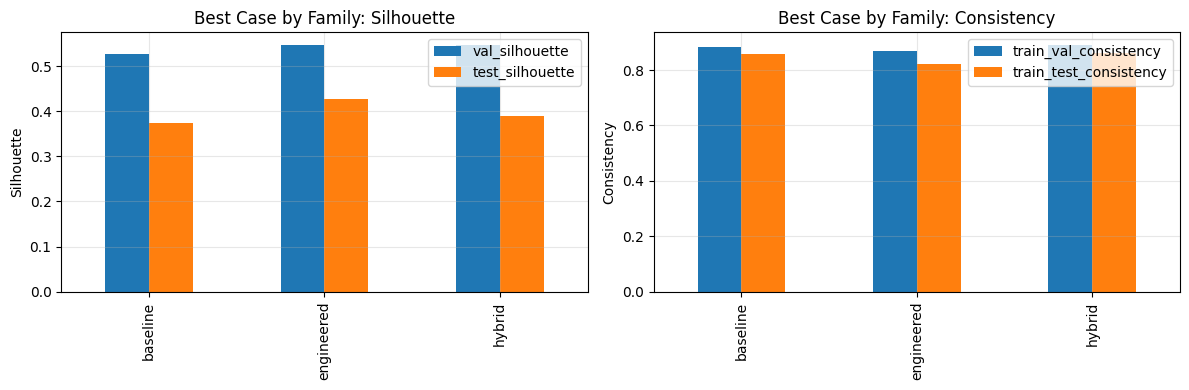

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = comparison.copy()
plot_df[["val_silhouette", "test_silhouette"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Best Case by Family: Silhouette")
axes[0].set_ylabel("Silhouette")
axes[0].grid(alpha=0.3)

plot_df[["train_val_consistency", "train_test_consistency"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Best Case by Family: Consistency")
axes[1].set_ylabel("Consistency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7) Final Clustering Run Using Best Overall Case

Best overall case is selected by highest validation silhouette (then test silhouette, then train silhouette).


In [12]:
best_case = feature_case_results_df.loc[0, "case"]
best_case_family = feature_case_results_df.loc[0, "family"]
best_features = FEATURE_CASES[best_case]["features"]

print("Best case:", best_case)
print("Family:", best_case_family)
print("Features:", best_features)

X_train = aggregate_features(train, best_features)
k_results, _ = evaluate_k_range(X_train, k_range=range(2, 9))
best_k = int(k_results.loc[k_results["silhouette"].idxmax(), "k"])

print("Selected k (train silhouette max):", best_k)
k_results


Best case: eng_case_medium
Family: engineered
Features: ['ret_abs_1', 'ret_std_10', 'hl_range_mean_21', 'vol_rel_21']
Selected k (train silhouette max): 2


,k,silhouette,inertia
0,2,0.571709,2396.666597
1,3,0.436510,1774.696742
2,4,0.395477,1509.782324
3,5,0.394517,1277.564165
4,6,0.352143,1057.183228
5,7,0.350334,912.401460
6,8,0.354748,788.787910


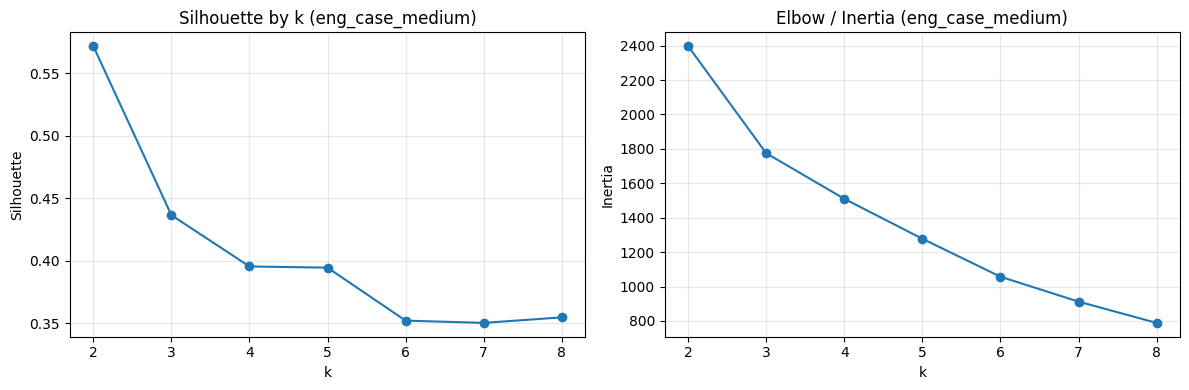

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_results["k"], k_results["silhouette"], marker="o")
plt.title(f"Silhouette by k ({best_case})")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.title(f"Elbow / Inertia ({best_case})")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
model, scaler, train_labels, train_score, X_train_scaled = fit_kmeans(X_train, k=best_k)

train_clusters = pd.DataFrame({"Symbol": X_train.index, "Cluster_train": train_labels})

X_val = aggregate_features(val, best_features)
X_val = X_val.loc[X_train.index.intersection(X_val.index)]
val_labels, val_score, X_val_scaled = apply_kmeans(X_val, model, scaler)
val_clusters = pd.DataFrame({"Symbol": X_val.index, "Cluster_val": val_labels})

X_test = aggregate_features(test, best_features)
X_test = X_test.loc[X_train.index.intersection(X_test.index)]
test_labels, test_score, X_test_scaled = apply_kmeans(X_test, model, scaler)
test_clusters = pd.DataFrame({"Symbol": X_test.index, "Cluster_test": test_labels})

stability_summary = pd.DataFrame(
    {"split": ["train", "validation", "test"], "silhouette": [train_score, val_score, test_score]}
)

stability_summary


,split,silhouette
0,train,0.571709
1,validation,0.547318
2,test,0.426591


In [15]:
train_val_compare = train_clusters.merge(val_clusters, on="Symbol", how="inner")
train_test_compare = train_clusters.merge(test_clusters, on="Symbol", how="inner")

train_val_consistency = (train_val_compare["Cluster_train"] == train_val_compare["Cluster_val"]).mean()
train_test_consistency = (train_test_compare["Cluster_train"] == train_test_compare["Cluster_test"]).mean()

print("Train silhouette:", round(train_score, 4))
print("Validation silhouette:", round(val_score, 4) if pd.notna(val_score) else np.nan)
print("Test silhouette:", round(test_score, 4) if pd.notna(test_score) else np.nan)
print("Train vs Validation consistency:", round(train_val_consistency, 4))
print("Train vs Test consistency:", round(train_test_consistency, 4))

train_profile = X_train.copy()
train_profile["Cluster"] = train_labels
cluster_profile = train_profile.groupby("Cluster").mean()

cluster_profile


Train silhouette: 0.5717
Validation silhouette: 0.5473
Test silhouette: 0.4266
Train vs Validation consistency: 0.8677
Train vs Test consistency: 0.8236


,ret_abs_1,ret_std_10,hl_range_mean_21,vol_rel_21,ret_abs_1_std,ret_std_10_std,hl_range_mean_21_std,vol_rel_21_std
Cluster,,,,,,,,
0,0.022767,0.029049,0.038545,1.015686,0.022562,0.013514,0.010944,0.554812
1,0.012627,0.016031,0.022284,1.011602,0.011811,0.006597,0.004943,0.443896


## 8) PCA View + Export Cluster Map

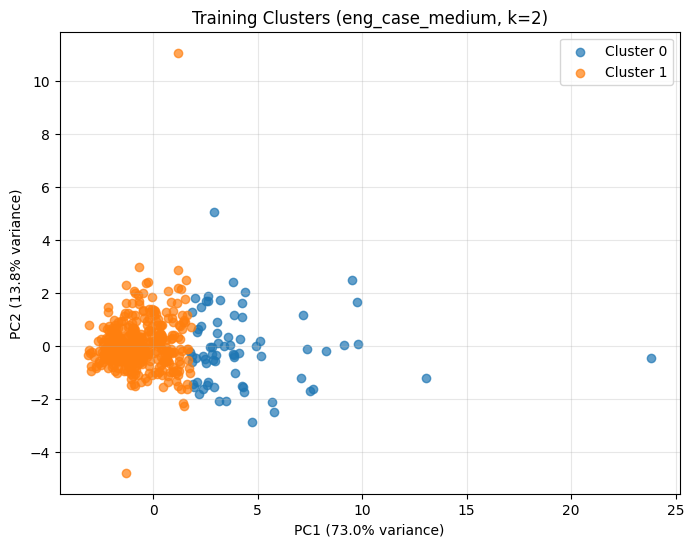

In [16]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))
for cluster in np.unique(train_labels):
    mask = train_labels == cluster
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], label=f"Cluster {cluster}", alpha=0.7)

plt.title(f"Training Clusters ({best_case}, k={best_k})")
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [17]:
cluster_map = train_clusters.copy().rename(columns={"Cluster_train": "cluster"})

profile_for_naming = X_train.copy()
profile_for_naming["cluster"] = train_labels
cluster_means = profile_for_naming.groupby("cluster").mean()

vol_candidates = [
    c
    for c in ["logvol_21", "logvol_5", "logvol_1", "ret_std_21", "ret_std_10", "ret_std_5"]
    if c in cluster_means.columns
]
name_map = {}

if len(vol_candidates) > 0 and len(cluster_means) >= 2:
    vcol = vol_candidates[0]
    ordered = cluster_means[vcol].sort_values()
    name_map[ordered.index[0]] = "Lower-vol / steadier"
    name_map[ordered.index[-1]] = "Higher-vol / riskier"

for c in sorted(cluster_map["cluster"].unique()):
    name_map.setdefault(c, f"Cluster {c}")

cluster_map["Cluster_name"] = cluster_map["cluster"].map(name_map)

output_path = "sp500_stock_cluster_map_feature_mix.csv"
cluster_map.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Rows:", len(cluster_map))
cluster_map.head()


Saved: sp500_stock_cluster_map_feature_mix.csv
Rows: 499


,Symbol,cluster,Cluster_name
0,A,1,Lower-vol / steadier
1,AAPL,1,Lower-vol / steadier
2,ABBV,1,Lower-vol / steadier
3,ABNB,0,Higher-vol / riskier
4,ABT,1,Lower-vol / steadier


In [4]:
# print number of stock counts in each cluster

import pandas as pd

df = pd.read_csv("data/sp500_stock_cluster_map_feature_mix.csv")
print(df["Cluster_name"].value_counts())

Cluster_name
Lower-vol / steadier    427
Higher-vol / riskier     72
Name: count, dtype: int64
